In [29]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

# Load dataset
diabetes = load_diabetes()
df = pd.DataFrame(diabetes.data, columns = diabetes.feature_names)
df['target'] = diabetes.target

In [30]:
# Step 2: Inspect Data Structure and Check Missing Values
df.info()
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


                age           sex           bmi            bp            s1  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean  -2.511817e-19  1.230790e-17 -2.245564e-16 -4.797570e-17 -1.381499e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02  4.761905e-02   
min   -1.072256e-01 -4.464164e-02 -9.027530e-02 -1.123988e-01 -1.267807e-01   
25%   -3.729927e-02 -4.464164e-02 -3.422907e-02 -3.665608e-02 -3.424784e-02   
50%    5.383060e-03 -4.464164e-02 -7.283766e-03 -5.670422e-03 -4.320866e-03   
75%    3.807591e-02  5.068012e-02  3.124802e-02  3.564379e-02  2.835801e-02   
max    1.107267e-01  5.068012e-02  1.705552e-01  1.320436e-01  1.539137e-01   

                 s2            s3            s4            s5            s6  \
count  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02  4.420000e+02   
mean   3.918434e-17 -5.777179e-18 -9.042540e-18  9.293722e-17  1.130318e-17   
std    4.761905e-02  4.761905e-02  4.761905e-02  4.

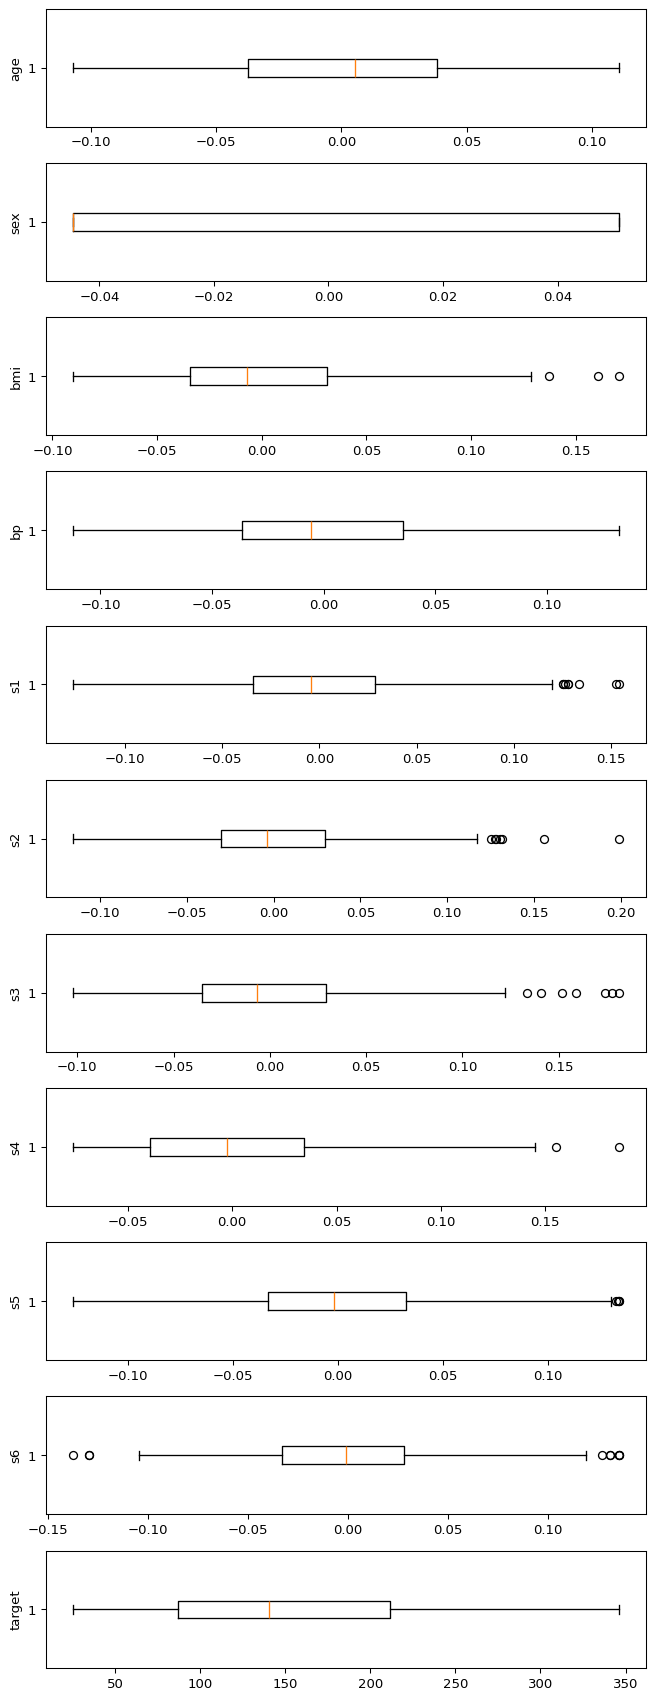

In [31]:
# Step 3: Statistical Summary and Visualizing Outliers
print(df.describe())

# Boxplots for each column
fig, axs = plt.subplots(len(df.columns), 1, figsize=(7, 18), dpi=95)
for i, col in enumerate(df.columns):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [32]:
# Step 4: Remove Outliers Using IQR Method (for all numeric features except target)
numeric_cols = df.drop(columns=['target']).columns

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Shape after outlier removal:", df.shape)

Shape after outlier removal: (407, 11)


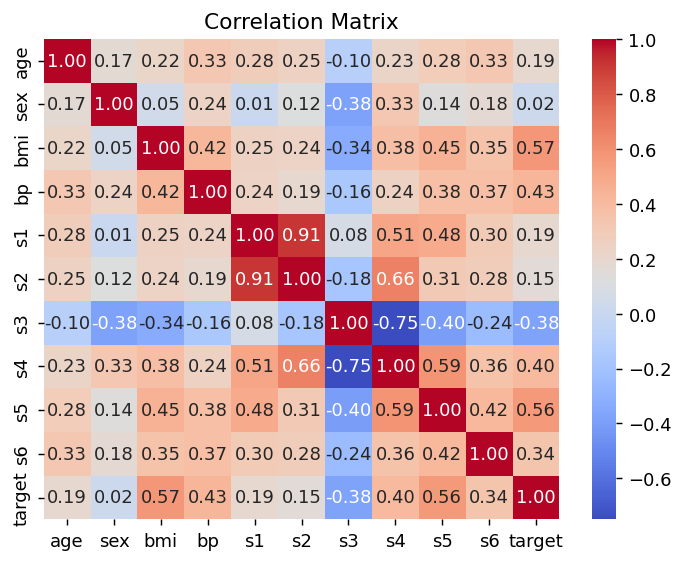

target    1.000000
bmi       0.574610
s5        0.557329
bp        0.430632
s4        0.402010
s6        0.340406
age       0.193537
s1        0.192543
s2        0.153082
sex       0.022752
s3       -0.375491
Name: target, dtype: float64


In [33]:
# Step 5: Correlation Analysis
corr = df.corr()

plt.figure(dpi=130)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

print(corr['target'].sort_values(ascending=False))

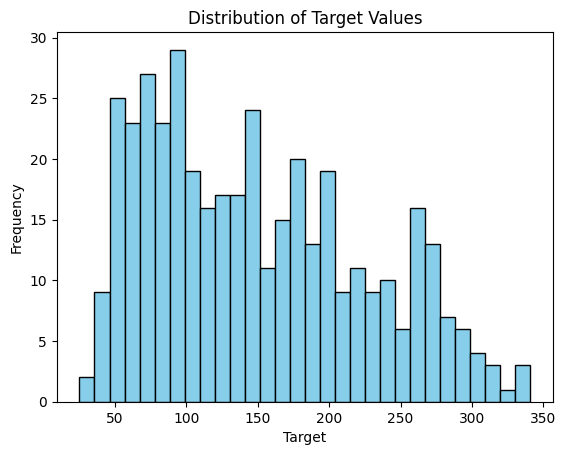

In [34]:
# Step 6: Visualize Target Variable Distribution (continuous regression target)
plt.hist(df['target'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Target Values')
plt.xlabel('Target')
plt.ylabel('Frequency')
plt.show()

In [35]:
# Step 7: Separate Features and Target Variable
X = df.drop(columns=['target'])
y = df['target']

In [36]:
# Step 8: Feature Scaling (Normalization & Standardization)

# Normalization (Min-Max Scaling)
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)
print("Normalized sample:\n", X_normalized[:5])

# Standardization (Z-score Scaling)
scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)
print("Standardized sample:\n", X_standardized[:5])

Normalized sample:
 [[0.66666667 1.         0.69458128 0.54929577 0.34883721 0.35983264
  0.26229508 0.33333333 0.59315632 0.38888889]
 [0.48333333 0.         0.1773399  0.35211268 0.5        0.42956764
  0.78688525 0.16666667 0.23467763 0.05555556]
 [0.88333333 1.         0.61576355 0.43661972 0.34302326 0.36262204
  0.31147541 0.33333333 0.52390475 0.35185185]
 [0.08333333 0.         0.35960591 0.30985915 0.5872093  0.62622036
  0.29508197 0.5        0.60445136 0.42592593]
 [0.51666667 0.         0.24630542 0.54929577 0.55232558 0.58437936
  0.49180328 0.33333333 0.38232789 0.25925926]]
Standardized sample:
 [[ 0.80565893  1.06343314  1.38124466  0.4831839  -0.90854505 -0.73667039
  -0.97747783  0.010936    0.52876202 -0.35329607]
 [-0.02677473 -0.9403506  -1.09453298 -0.55158235 -0.0838561  -0.37646417
   1.7453692  -0.83686474 -1.45028603 -2.03506798]
 [ 1.78944416  1.06343314  1.0039833  -0.1081111  -0.94026385 -0.72226214
  -0.72221092  0.010936    0.14644592 -0.54015961]
 [-1.84